In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Zadanie 1

In [2]:
x0 = 1.0
machine_epsilon = np.finfo(float).eps
k = np.arange(17)
h = 10.0**(-k)

In [32]:
f_x0 = np.tan(x0)
exact_derivative = 1.0 + f_x0**2
exact_second_derivative = 2.0 * f_x0 * exact_derivative
exact_third_derivative = 6* f_x0**4 + 8* f_x0**2 + 2

#### Wartość pochodniej w prost

In [33]:
approx_derivative = (np.tan(x0 + h) - f_x0) / h

In [34]:
error_computational = np.abs(approx_derivative - exact_derivative)
error_method = (np.abs(exact_second_derivative) / 2.0) * h
error_numerical = (2.0 * machine_epsilon * np.abs(f_x0)) / h

In [35]:
h_min_empirical = h[np.argmin(error_computational)]
h_min_theoretical = 2.0 * np.sqrt(machine_epsilon / np.abs(exact_second_derivative))

#### Wartość pochodnej ze wzoru roznic centralnych

In [54]:
approx_central_derivative = (np.tan(x0 + h) - np.tan(x0 - h)) / (2.0 * h)

In [55]:
central_error_computational = np.abs(approx_central_derivative - exact_derivative)
central_error_method = (np.abs(exact_third_derivative) / 6.0) * h**2
central_error_numerical = (machine_epsilon * np.abs(f_x0)) / h

In [56]:
central_h_min_empirical = h[np.argmin(central_error_computational)]
central_h_min_theoretical = np.cbrt(3.0 * machine_epsilon / np.abs(exact_third_derivative))

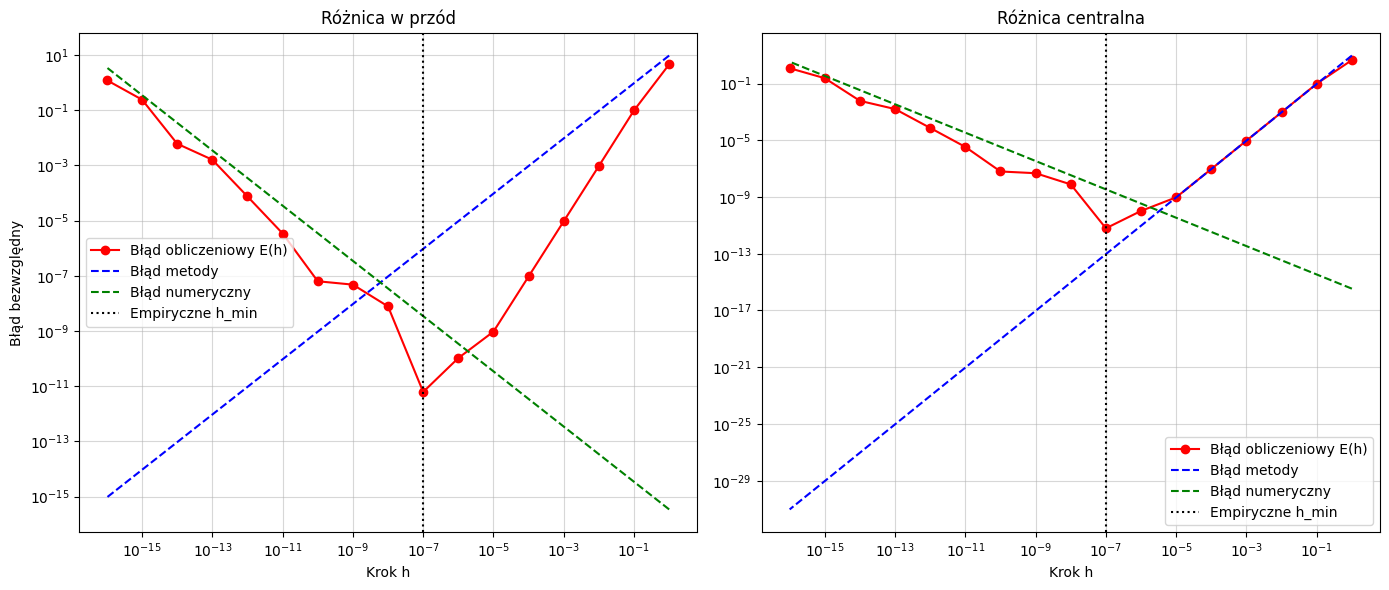

In [70]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Wykres 1: Różnica w przód ---
axs[0].loglog(h, error_computational, 'ro-', label='Błąd obliczeniowy E(h)')
axs[0].loglog(h, error_method, 'b--', label='Błąd metody')
axs[0].loglog(h, error_numerical, 'g--', label='Błąd numeryczny')
axs[0].axvline(h_min_empirical, color='k', linestyle=':', label='Empiryczne h_min')

axs[0].set_xlabel('Krok h')
axs[0].set_ylabel('Błąd bezwzględny')
axs[0].set_title('Różnica w przód')
axs[0].grid(True, which="both", ls="-", alpha=0.5)
axs[0].legend()

# --- Wykres 2: Różnica centralna ---
axs[1].loglog(h, central_error_computational, 'ro-', label='Błąd obliczeniowy E(h)')
axs[1].loglog(h, central_error_method, 'b--', label='Błąd metody')
axs[1].loglog(h, central_error_numerical, 'g--', label='Błąd numeryczny')
axs[1].axvline(central_h_min_empirical, color='k', linestyle=':', label='Empiryczne h_min')

axs[1].set_xlabel('Krok h')
axs[1].set_title('Różnica centralna')
axs[1].grid(True, which="both", ls="-", alpha=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()

## Zadanie 2

(a) $f(x) = \sqrt{x + 1} - 1$ dla $x \approx 0$
Wersja stabilna: $\frac{x}{\sqrt{x + 1} + 1}$

(b) $f(x, y) = x^2 - y^2$ dla $x \approx y$
Wersja stabilna: $(x - y)(x + y)$

(c) $f(x) = \frac{1 - \cos x}{\sin x}$ dla $x \approx 0
Wersja stabilna: $\frac{\sin x}{1 + \cos x}$ lub bezpośrednio $\tan(\frac{x}{2})$

(d) $f(x, y) = \sin x - \sin y$ dla $x \approx y$
Wersja stabilna: $2 \sin(\frac{x - y}{2}) \cos(\frac{x + y}{2})$

(e) $f(a, b) = \frac{a + b}{2}$ 
Wersja stabilna: $a + \frac{b - a}{2}$ dla a,b tych samych znaków, $\frac{a + b}{2}$ gdy sa przeciwnych znaków

(f) $\text{softmax}(x)_i = \frac{\exp(x_i)}{\sum_j \exp(x_j)}$
Wersja stabilna: $\frac{\exp(x_i - \max(x))}{\sum_j \exp(x_j - \max(x))}$

In [65]:
import decimal
decimal.getcontext().prec = 5

#### Podpunkt (a)

In [66]:
x_val_a = decimal.Decimal('1e-4') # x = 0.0001
one = decimal.Decimal('1')

In [67]:
unstable_a = (x_val_a + one).sqrt() - one
stable_a = x_val_a / ((x_val_a + one).sqrt() + one)

In [68]:
print("--- Podpunkt (a): sqrt(x + 1) - 1 dla x bliskiego 0 ---")
print(f"Dane wejściowe: x = {x_val_a}")
print(f"Wynik niestabilny: {unstable_a}")
print(f"Wynik stabilny:    {stable_a}\n")

--- Podpunkt (a): sqrt(x + 1) - 1 dla x bliskiego 0 ---
Dane wejściowe: x = 0.0001
Wynik niestabilny: 0.0000
Wynik stabilny:    0.00005



#### Podpunkt (b)

In [62]:
x_val = decimal.Decimal('100.01')
y_val = decimal.Decimal('100.00')

In [63]:
unstable_b = x_val**2 - y_val**2
stable_b = (x_val - y_val) * (x_val + y_val)

In [64]:
print("--- Podpunkt (b): x^2 - y^2 dla x ~ y ---")
print(f"Dane: x = {x_val}, y = {y_val}")
print(f"Wynik niestabilny: {unstable_b}")
print(f"Wynik stabilny:    {stable_b}\n")

--- Podpunkt (b): x^2 - y^2 dla x ~ y ---
Dane: x = 100.01, y = 100.00
Wynik niestabilny: 2
Wynik stabilny:    2.0001

